Importación de librerias

In [ ]:
# Manejo de datos
import pandas as pd                 # Análisis y manipulación de datos en tablas
import numpy as np                  # Cálculos numéricos y matrices
import os                           # Gestión de rutas de archivos

# Visualización de datos
import matplotlib.pyplot as plt     # Gráficos básicos en 2D
import seaborn as sns               # Gráficos estadísticos mejorados
import plotly.express as px         # Gráficos interactivos simplificados
import plotly.graph_objects as go   # Control avanzado de gráficos en Plotly
import plotly.io as pio             # Interfaz de entrada/salida de Plotly
import matplotlib.gridspec as gridspec  #Gráficos en rejilla

# Procesado y análisis
from scipy import stats              # Funciones estadísticas
from scipy.stats import chi2_contingency, norm, ttest_ind, f_oneway # Pruebas de hipótesis y análisis estadístico
from matplotlib.patches import Patch  # Añadir parches a los gráficos de Matplotlib
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler  # Escalado de datos
from sklearn.decomposition import PCA  # Análisis de componentes principales

Ruta de acceso a Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ruta = '/content/drive/MyDrive/Data Science - Grupo 4 /Data/tablas_extraidas_Orphadata'


if os.path.exists(ruta):
    print(f"Contenido de {ruta}:\n")
    archivos = os.listdir(ruta)
    for archivo in archivos:
        print(" -", archivo)
else:
    print(f"❌ La ruta no existe:\n{ruta}")

Contenido de /content/drive/MyDrive/Data Science - Grupo 4 /Data/tablas_extraidas_Orphadata:

 - df_rd_classification.csv
 - df_rd_list.csv
 - df_diseases.csv
 - df_genes.csv
 - df_disease_gene.csv
 - df_rd_epidemiology.csv
 - df_rd_history.csv
 - df_rd_functional_consequences.csv
 - df_rd_phenotypes.csv


Carga de archivos.csv a un diccionario

In [ ]:
orphadata = {}

for archivo in os.listdir(ruta):
    if archivo.endswith('.csv'):
        # Eliminar 'df_' i 'rd_' del nombre del archivo
        nombre_limpio = archivo.replace('.csv', '').replace('df_', '').replace('rd_', '')
        nombre_clave = nombre_limpio.lower().replace(' ', '_')
        ruta_completa = os.path.join(ruta, archivo)

        try:
            df = pd.read_csv(ruta_completa)
            orphadata[nombre_clave] = df
            print(f"Cargado: {nombre_clave} ({df.shape[0]} filas, {df.shape[1]} columnas)")
        except Exception as e:
            print(f"Error al cargar {archivo}: {e}")

Cargado: classification (35 filas, 2 columnas)
Cargado: list (11074 filas, 2 columnas)
Cargado: diseases (27613 filas, 3 columnas)
Cargado: genes (4478 filas, 3 columnas)
Cargado: disease_gene (8193 filas, 9 columnas)
Cargado: epidemiology (16119 filas, 10 columnas)
Cargado: history (6994 filas, 9 columnas)
Cargado: functional_consequences (1046 filas, 3 columnas)
Cargado: phenotypes (114961 filas, 5 columnas)


Limpieza de datos

In [ ]:
# Estándarización de columnas de los dataframes

# En diseases → renombrar 'class_hchId' a 'hchId'
orphadata['diseases'].rename(columns={'class_hchId': 'hchId'}, inplace=True)

# En epidemiology → renombrar 'Code Disease' a 'ORPHAcode'
orphadata['epidemiology'].rename(columns={'Code Disease': 'ORPHAcode'}, inplace=True)

# En disease_gene → renombrar 'name' a 'Gene name' y 'symbol' a 'Gene symbol'
orphadata['disease_gene'].rename(columns={
    'name': 'Gene name',
    'symbol': 'Gene symbol'
}, inplace=True)

# En functional_consequences → renombrar 'Código Orphanet' y 'Nombre'
orphadata['functional_consequences'].rename(columns={
    'Código Orphanet': 'ORPHAcode',
    'Nombre': 'disease_name'
}, inplace=True)

In [ ]:
#Eliminación de columnas no necesarias
orphadata['functional_consequences'] = orphadata['functional_consequences'].drop(columns=['Consecuencias Funcionales'])
orphadata['disease_gene'] = orphadata['disease_gene'].drop(columns=['Validation source'])
orphadata['diseases'] = orphadata['diseases'].drop(columns=['hchId'])
orphadata['epidemiology'] = orphadata['epidemiology'].drop(columns=['ValMoy', 'PrevalenceValidationStatus', 'Source'])

In [ ]:
# Muestra las columnas de cada tabla
for nombre, df in orphadata.items():
    print(f"\n📄 {nombre} ({df.shape[0]} files):")
    print(list(df.columns))


📄 classification (35 files):
['hchId', 'hchTag']

📄 list (11074 files):
['ORPHAcode', 'Preferred term']

📄 diseases (27613 files):
['ORPHAcode', 'preferredTerm']

📄 genes (4478 files):
['HGNC', 'name', 'symbol']

📄 disease_gene (8193 files):
['ORPHAcode', 'Disorder name', 'Disorder type', 'Gene symbol', 'Gene name', 'Gene type', 'Gene synonyms', 'Locus']

📄 epidemiology (16119 files):
['ORPHAcode', 'Preferred term', 'Typology', 'PrevalenceType', 'PrevalenceClass', 'PrevalenceQualification', 'PrevalenceGeographic']

📄 history (6994 files):
['data', 'AverageAgeOfOnset', 'Date', 'DisorderGroup', 'ORPHAcode', 'OrphanetURL', 'Preferred term', 'TypeOfInheritance', 'Typology']

📄 functional_consequences (1046 files):
['disease_name', 'ORPHAcode']

📄 phenotypes (114961 files):
['ORPHAcode', 'Disorder', 'HPO_ID', 'HPO_Term', 'Frequency']


In [ ]:
# Copiar y renombrar columnas similares para diferenciarlas

lista_final = orphadata['list'].rename(columns={
    'Preferred term': 'Preferred_term_list'
})

functional_consequence_final = orphadata['functional_consequences'].rename(columns={
    'disease_name': 'Disease_name_func'
})

disease_gene_final = orphadata['disease_gene'].rename(columns={
    'Disorder name': 'Disease_name_dg'
})

phenotypes_final = orphadata['phenotypes'].rename(columns={
    'Disorder': 'Disease_name_pheno'
})

diseases_final = orphadata['diseases'].rename(columns={
    'preferredTerm': 'Preferred_term_diseases'
})

epidemiology_final = orphadata['epidemiology'].rename(columns={
    'Preferred term': 'Preferred_term_epi'
})

Diccionario de tablas finales

In [ ]:
tablas_finales = {
    'list': lista_final,
    'functional_consequences': functional_consequence_final,
    'disease_gene': disease_gene_final,
    'phenotypes': phenotypes_final,
    'diseases': diseases_final,
    'epidemiology': epidemiology_final
}
print(tablas_finales.keys())

dict_keys(['list', 'functional_consequences', 'disease_gene', 'phenotypes', 'diseases', 'epidemiology'])


In [ ]:
for nombre, df in tablas_finales.items():
    print(f"\n📄 {nombre} ({df.shape[0]} files):")
    print(list(df.columns))


📄 list (11074 files):
['ORPHAcode', 'Preferred_term_list']

📄 functional_consequences (1046 files):
['Disease_name_func', 'ORPHAcode']

📄 disease_gene (8193 files):
['ORPHAcode', 'Disease_name_dg', 'Disorder type', 'Gene symbol', 'Gene name', 'Gene type', 'Gene synonyms', 'Locus']

📄 phenotypes (114961 files):
['ORPHAcode', 'Disease_name_pheno', 'HPO_ID', 'HPO_Term', 'Frequency']

📄 diseases (27613 files):
['ORPHAcode', 'Preferred_term_diseases']

📄 epidemiology (16119 files):
['ORPHAcode', 'Preferred_term_epi', 'Typology', 'PrevalenceType', 'PrevalenceClass', 'PrevalenceQualification', 'PrevalenceGeographic']


Merge de dataframes, limpieza y visualización

In [ ]:
#MERGE
df_merged = tablas_finales['list'] \
    .merge(tablas_finales['diseases'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['phenotypes'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['functional_consequences'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['epidemiology'], on='ORPHAcode', how='left') \
    .merge(tablas_finales['disease_gene'], on='ORPHAcode', how='left')

In [ ]:
df_merged['Disease_name_unificado'] = df_merged[
    ['Disease_name_func', 'Disease_name_dg', 'Disease_name_pheno']
].bfill(axis=1).iloc[:, 0]

df_merged.drop(columns=['Disease_name_func', 'Disease_name_dg', 'Disease_name_pheno'], inplace=True)

/tmp/ipython-input-12-3479528273.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].bfill(axis=1).iloc[:, 0]


In [ ]:
df_merged['Preferred_term_unificado'] = df_merged[
    ['Preferred_term_list', 'Preferred_term_diseases', 'Preferred_term_epi']
].bfill(axis=1).iloc[:, 0]

df_merged.drop(columns=['Preferred_term_list', 'Preferred_term_diseases', 'Preferred_term_epi'], inplace=True)

In [ ]:
df_merged['Disorder_type_unificado'] = df_merged[
    ['Disorder type', 'Typology']
].bfill(axis=1).iloc[:, 0]

df_merged.drop(columns=['Disorder type', 'Typology'], inplace=True)

/tmp/ipython-input-14-2913094727.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].bfill(axis=1).iloc[:, 0]


In [ ]:
print(df_merged.columns)

Index(['ORPHAcode', 'HPO_ID', 'HPO_Term', 'Frequency', 'PrevalenceType',
       'PrevalenceClass', 'PrevalenceQualification', 'PrevalenceGeographic',
       'Gene symbol', 'Gene name', 'Gene type', 'Gene synonyms', 'Locus',
       'Disease_name_unificado', 'Preferred_term_unificado',
       'Disorder_type_unificado'],
      dtype='object')


In [ ]:
df_merged.head()

,ORPHAcode,HPO_ID,HPO_Term,Frequency,PrevalenceType,PrevalenceClass,PrevalenceQualification,PrevalenceGeographic,Gene symbol,Gene name,Gene type,Gene synonyms,Locus,Disease_name_unificado,Preferred_term_unificado,Disorder_type_unificado
0,166024,HP:0000207,Triangular mouth,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
1,166024,HP:0000207,Triangular mouth,Very frequent (99-80%),Point prevalence,<1 / 1 000 000,Class only,Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
2,166024,HP:0000256,Macrocephaly,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
3,166024,HP:0000256,Macrocephaly,Very frequent (99-80%),Point prevalence,<1 / 1 000 000,Class only,Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease
4,166024,HP:0000316,Hypertelorism,Very frequent (99-80%),Cases/families,NaN,Case(s),Worldwide,KIF7,kinesin family member 7,gene with protein product,['JBTS12'],"[{'GeneLocus': '15q26.1', 'LocusKey': 1}]",Multiple epiphyseal dysplasia-macrocephaly-fac...,Multiple epiphyseal dysplasia-macrocephaly-fac...,Disease


**Clustering con OPTICS.**
OPTICS (Ordering Points To Identify the Clustering Structure) es un algoritmo de clustering basado en densidad que identifica grupos de datos de forma jerárquica. OPTICS no requiere un umbral de densidad fijo, sino que produce un "orden de procesamiento" de los puntos que revela la estructura de los clusters a diferentes densidades, permitiendo extraer clusters de densidad variable.

In [ ]:
# Transformación de las frecuencias cualitativas a valores numéricos
freq_map = {
    "Obligate (100%)": 1.00,                  # 100%
    "Very frequent (99-80%)": 0.895,          # promedio: (99+80)/2 = 89.5%
    "Frequent (79-30%)": 0.545,               # (79+30)/2 = 54.5%
    "Occasional (29-5%)": 0.17,               # (29+5)/2 = 17%
    "Rare (<4%)": 0.02,                       # asumimos 2%
    "Excluded (0%)": 0.0,
    np.nan: np.nan                            # dejamos como NaN real
}

df_merged['frequency_numeric'] = df_merged['Frequency'].map(freq_map).fillna(0)

In [ ]:
# Pivotar a matriz enfermedades x síntomas
df_pivot = df_merged.pivot_table(index='ORPHAcode',
                                 columns='HPO_ID',
                                 values='frequency_numeric',
                                 aggfunc='max',
                                 fill_value=0)

In [ ]:
#Escalado de los datos

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = StandardScaler().fit_transform(df_pivot)


In [ ]:
#Reducción de la dimensionalidad PCA

X_pca = PCA(n_components=50).fit_transform(X_scaled)

In [ ]:
# Clustering

from sklearn.cluster import OPTICS

clust = OPTICS(min_samples=6).fit(X_pca)

# Ver etiquetas y número de clústeres
import numpy as np
labels = clust.labels_
print("Etiquetas únicas asignadas por OPTICS:", np.unique(labels))


Etiquetas únicas asignadas por OPTICS: [-1  0  1  2]


In [ ]:
import numpy as np

n_clusters = len(set(clust.labels_)) - (1 if -1 in clust.labels_ else 0)
print(f"Número de clústeres detectados: {n_clusters}")


Número de clústeres detectados: 3


In [ ]:
# hago un loop para ver cuantos clusters crea para cada min_samples distinto
range_n = range(2, 12)
scores = []

for k in range_n:
    optics_model = OPTICS(min_samples=k)
    optics_model.fit(X_pca)
    labels = optics_model.labels_
    n_clusters = len(np.unique(labels)) - 1
    print(f"k={k}, Número de clusters encontrados={n_clusters}")

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_optics.py:1086: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


k=2, Número de clusters encontrados=404
k=3, Número de clusters encontrados=94
k=4, Número de clusters encontrados=35
k=5, Número de clusters encontrados=8
k=6, Número de clusters encontrados=3
k=7, Número de clusters encontrados=1
k=8, Número de clusters encontrados=1
k=9, Número de clusters encontrados=1
k=10, Número de clusters encontrados=1
k=11, Número de clusters encontrados=1


Haciendo este loop, vemos que una buena opción es escoger min_cluster_size = 5 porque representa un equilibrio razonable entre una fragmentación excesiva del conjunto de datos (como ocurre con valores menores, que generan demasiados clusters poco informativos) y una agrupación demasiado general (como ocurre con valores mayores, que apenas detectan un cluster). Con este valor, el algoritmo OPTICS identifica 8 clusters bien definidos, lo que permite una exploración significativa de la estructura de los datos sin perder granularidad ni sobreajustar.

In [ ]:
# ¿Cómo de bien está definido el cluster? Silhouette score

from sklearn.cluster import OPTICS
from sklearn.metrics import silhouette_score
import numpy as np

range_n = range(2, 12)
validity_scores = []

for k in range_n:
    optics_model = OPTICS(min_samples=k)
    optics_model.fit(X_pca)
    labels = optics_model.labels_

    # Silhouette requiere al menos 2 clusters distintos
    if len(set(labels)) > 1 and len(set(labels)) != 1 + (1 if -1 in labels else 0):
        # Excluimos puntos de ruido (-1) porque silhouette no los soporta
        mask = labels != -1
        score = silhouette_score(X_pca[mask], labels[mask])
        validity_scores.append(score)
        print(f"min_samples={k}, Silhouette Score={score:.4f}")
    else:
        validity_scores.append(np.nan)
        print(f"min_samples={k}, Silhouette Score=NA (solo un cluster o todo ruido)")

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_optics.py:1086: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


min_samples=2, Silhouette Score=0.3713
min_samples=3, Silhouette Score=0.4766
min_samples=4, Silhouette Score=0.5374
min_samples=5, Silhouette Score=0.6765
min_samples=6, Silhouette Score=0.8613
min_samples=7, Silhouette Score=NA (solo un cluster o todo ruido)
min_samples=8, Silhouette Score=NA (solo un cluster o todo ruido)
min_samples=9, Silhouette Score=NA (solo un cluster o todo ruido)
min_samples=10, Silhouette Score=NA (solo un cluster o todo ruido)
min_samples=11, Silhouette Score=NA (solo un cluster o todo ruido)


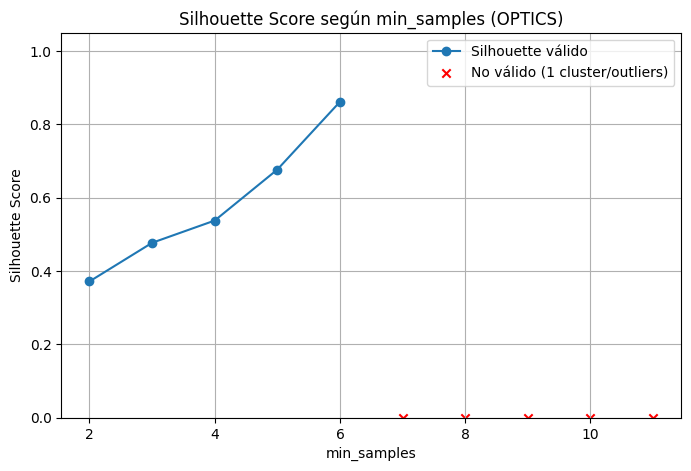

In [ ]:
import matplotlib.pyplot as plt

# Convertimos range_n a lista para alinearlo con validity_scores
min_samples_vals = list(range_n)

# Separar valores válidos y NaN para la visualización
valid_x = [x for x, s in zip(min_samples_vals, validity_scores) if not np.isnan(s)]
valid_y = [s for s in validity_scores if not np.isnan(s)]
na_x = [x for x, s in zip(min_samples_vals, validity_scores) if np.isnan(s)]

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(valid_x, valid_y, marker='o', label='Silhouette válido')
plt.scatter(na_x, [0]*len(na_x), color='red', marker='x', label='No válido (1 cluster/outliers)')
plt.xlabel('min_samples')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score según min_samples (OPTICS)')
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()


 Esto sugiere que min_samples = 6 es el valor máximo antes de que OPTICS colapse a un único cluster. Nos quedamos con este valor

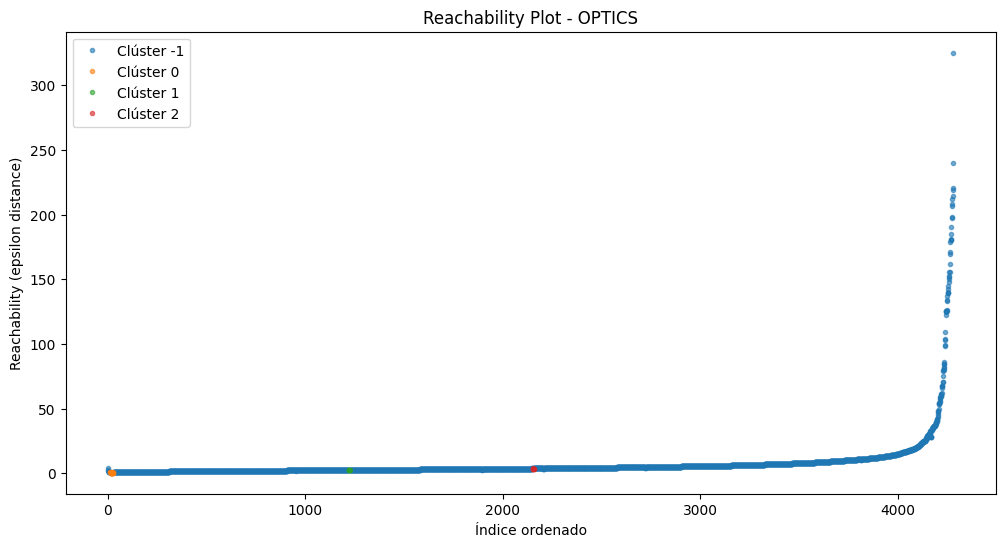

In [ ]:
# Reachability plot
import matplotlib.gridspec as gridspec

space = np.arange(len(X_pca))
reachability = clust.reachability_[clust.ordering_]
ordering_labels = clust.labels_[clust.ordering_]

plt.figure(figsize=(12, 6))
for klass in np.unique(ordering_labels):
    mask = ordering_labels == klass
    plt.plot(space[mask], reachability[mask], '.', alpha=0.6, label=f'Clúster {klass}')
plt.ylabel('Reachability (epsilon distance)')
plt.xlabel('Índice ordenado')
plt.title('Reachability Plot - OPTICS')
plt.legend()
plt.show()


Visualización con t-SNE

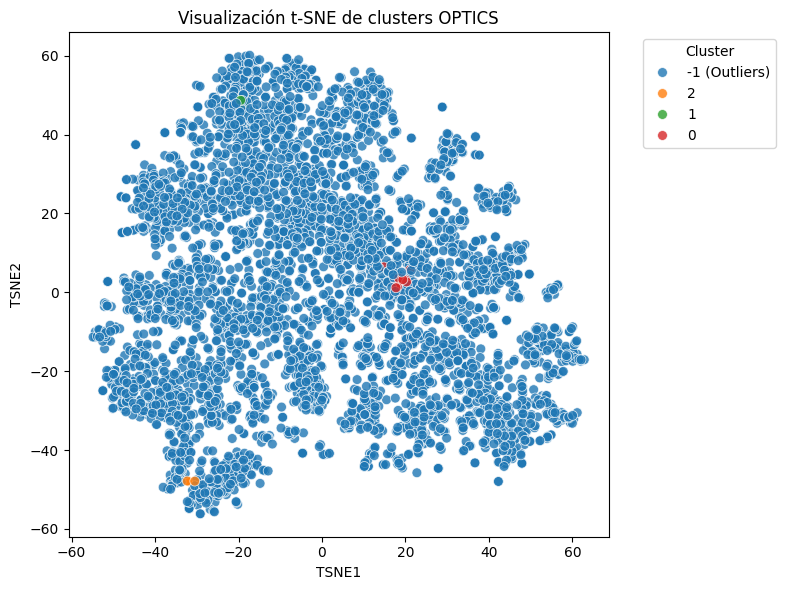

In [ ]:
# Visualizamos con t-SNE

tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X_pca)

# Crea un DataFrame con los resultados y las etiquetas
df_tsne = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'Cluster': labels.astype(str)  # Convertimos a str para manejar '-1'
})

# Opcional: reemplaza la etiqueta '-1' por 'Noise' para que se vea claro en la leyenda
df_tsne.loc[df_tsne['Cluster'] == '-1', 'Cluster'] = '-1 (Outliers)'

# Paleta automática según el número de clusters únicos
num_clusters = df_tsne['Cluster'].nunique()
palette = sns.color_palette('tab10', n_colors=num_clusters)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='Cluster', palette=palette, s=50, alpha=0.8)
plt.title('Visualización t-SNE de clusters OPTICS')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
